In [27]:
import numpy as np
import h5py
from matplotlib import pyplot as plt
import pandas as pd

FIGSIZE=(5,3)
SAVE_PLOTS=True

In [28]:
def load_h5_data(filename):
    data = {}
    with h5py.File(filename, 'r') as f:
        for voltage in f.keys():
            data[int(voltage)] = {'CH1': [], 'CH2': []}

            for i in f[voltage]['CH1']:
                arr = np.array(f[voltage]['CH1'][i])  # Load as NumPy array
                df = pd.DataFrame(arr, columns=['t', 'V'])  # Convert to DataFrame
                data[int(voltage)]['CH1'].append(df)

            for i in f[voltage]['CH2']:
                arr = np.array(f[voltage]['CH2'][i])
                df = pd.DataFrame(arr, columns=['t', 'V'])
                data[int(voltage)]['CH2'].append(df)
    return data


In [29]:
data = load_h5_data('data/gain_fixed_light/pmt1/signals.h5')
data 

{1000: {'CH1': [             t      V
   0    -0.000490  0.008
   1    -0.000489  0.008
   2    -0.000488  0.008
   3    -0.000487  0.008
   4    -0.000486  0.000
   ...        ...    ...
   2447  0.001957  0.016
   2448  0.001958  0.008
   2449  0.001959  0.008
   2450  0.001960  0.008
   2451  0.001961  0.008
   
   [2452 rows x 2 columns],
                t      V
   0    -0.000490 -0.016
   1    -0.000489 -0.008
   2    -0.000488  0.008
   3    -0.000487  0.008
   4    -0.000486  0.008
   ...        ...    ...
   2447  0.001957  0.000
   2448  0.001958  0.000
   2449  0.001959  0.008
   2450  0.001960  0.000
   2451  0.001961  0.000
   
   [2452 rows x 2 columns],
                t      V
   0    -0.000490  0.016
   1    -0.000489  0.008
   2    -0.000488  0.008
   3    -0.000487  0.008
   4    -0.000486  0.008
   ...        ...    ...
   2447  0.001957  0.000
   2448  0.001958  0.000
   2449  0.001959  0.000
   2450  0.001960  0.000
   2451  0.001961  0.000
   
   [2452 rows x 2 c

In [30]:
def select_waveform(data, voltage, channel):
    waveforms = data[voltage][channel]
    waveforms.sort(key=lambda x: x['V'].min())  # Sort by time
    df = waveforms[2]
    # select time between -400 and 1000 us
    df = df[(df['t'] > -400e-6) & (df['t'] < 1000e-6)] 
    return df
df = select_waveform(data, 1450, 'CH1')
df['us'] = df['t'] * 1e6
df

/tmp/ipykernel_178674/2757506274.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['us'] = df['t'] * 1e6


,t,V,us
90,-0.000400,-0.16,-400.0
91,-0.000399,-0.16,-399.0
92,-0.000398,-0.16,-398.0
93,-0.000397,-0.16,-397.0
94,-0.000396,-0.16,-396.0
...,...,...,...
1485,0.000995,-0.16,995.0
1486,0.000996,-0.16,996.0
1487,0.000997,-0.16,997.0
1488,0.000998,-0.24,998.0


t1: -48.000000000 us
t2: -45.000000000 us
tau: 140.651286881 us
fall time 10%:  -323.86155648204743
fall time 90%:  -14.81909211369284
fall time 90%-10%:  309.0424643683546
Rise time: 3.000000000 us


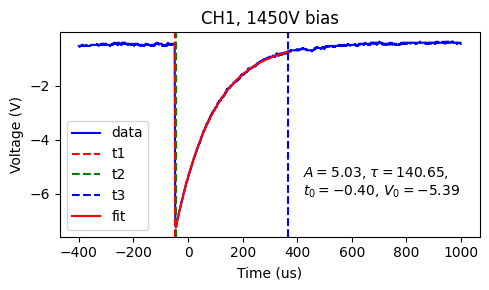

In [52]:
fig, ax = plt.subplots(figsize=FIGSIZE)
# ax.plot(df['us'], df['V'])
ax.plot(df['us'], df['V'], 'b-', label='data')
ax.set_xlabel('Time (us)')
ax.set_ylabel('Voltage (V)')
ax.set_title('CH1, 1450V bias')

def find_begin_end_rise(df):
    threshold = 0.1 * df['V'].min()
    index = df[df['V'] < threshold].index[0]
    t1 = df['us'][index]
    max_index = df['V'].idxmin()
    t2 = df['us'][max_index]
    return t1, t2

def find_rise_time(df):
    t1, t2 = find_begin_end_rise(df)
    print(f"t1: {t1:.9f} us")
    print(f"t2: {t2:.9f} us")
    return t2 - t1

def find_begin_end_fall(df):
    threshold = 0.1*df['V'].min()
    index = df[df['V'] < threshold].index[-1]
    t2 = df['us'][index]
    max_index = df['V'].idxmin()
    t1 = df['us'][max_index]
    return t1, t2

rise_time = find_rise_time(df)
t1, t2 = find_begin_end_rise(df)
ax.axvline(x=t1, color='r', linestyle='--', label='t1')
ax.axvline(x=t2, color='g', linestyle='--', label='t2')
_, t3 = find_begin_end_fall(df)
ax.axvline(x=t3, color='b', linestyle='--', label='t3')

# fit an exponential to the fall time
from scipy.optimize import curve_fit

def exp_func(x, A, tau, t_0, V_0):
    return A * (1 - np.exp(-(x - t_0) / tau)) + V_0

df_fit = df[(df['us'] > t2) & (df['us'] < t3)]
t = df_fit['us'].values
v = df_fit['V'].values
popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[4, 1, 1,0])
ax.plot(t, exp_func(t, *popt), 'r-', label=rf'fit')

plt.text(0.58, 0.2, rf'$A={popt[0]:.2f}$, $\tau={popt[1]:.2f}$,' + '\n' + rf'$t_0={popt[2]:.2f}$, $V_0={popt[3]:.2f}$', color='black', transform=plt.gca().transAxes)

tau = popt[1]
print(f"tau: {tau:.9f} us")
t_10 = np.log(0.1) * tau
t_90 = np.log(0.9) * tau
print('fall time 10%: ', t_10)
print('fall time 90%: ', t_90)
print('fall time 90%-10%: ', t_90 - t_10)

# ax.plot(df_fit['us'], df_fit['V'], 'r-', label='data')

plt.legend()

plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig('plots/pmt_signal_tests/pmt1/example_time_fitting.png', dpi=300)

print(f"Rise time: {rise_time:.9f} us")

In [32]:
def calculate_fall_time(df):
    v_min = df['V'].min()
    t1, t2 = find_begin_end_fall(df)
    df_fit = df[(df['us'] > t1) & (df['us'] < t2)]
    t = df_fit['us'].values
    v = df_fit['V'].values

    popt, pcov = curve_fit(exp_func, t, v, maxfev=10000, p0=[4,1,1, v_min])
    tau = popt[1]
    t_10 = np.log(0.1) * tau
    t_90 = np.log(0.9) * tau
    t_fall = t_90 - t_10
    return t_fall

In [33]:
voltages = sorted(data.keys())
voltages = np.array(voltages)
voltages = voltages[np.where(np.array(voltages) > 1000)]
voltages = voltages[np.where(np.array(voltages) < 1600)]

In [34]:
rise_times_ch1 = []
fall_times_ch1 = []
rise_times_ch2 = []
fall_times_ch2 = []


for v in voltages:
    df = select_waveform(data, v, 'CH1')
    df = df.copy()
    df['us'] = df['t'] * 1e6
    rise_time = find_rise_time(df)
    rise_times_ch1.append(rise_time)
    fall_time = calculate_fall_time(df)
    fall_times_ch1.append(fall_time)

    df = select_waveform(data, v, 'CH2')
    df = df.copy()
    df['us'] = df['t'] * 1e6
    rise_time = find_rise_time(df)
    rise_times_ch2.append(rise_time)
    fall_time = calculate_fall_time(df)
    fall_times_ch2.append(fall_time)


fall_times_ch1 = np.array(fall_times_ch1)
rise_times_ch1 = np.array(rise_times_ch1)
fall_times_ch2 = np.array(fall_times_ch2)
rise_times_ch2 = np.array(rise_times_ch2)

t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -48.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -48.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -47.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -47.000000000 us
t2: -46.000000000 us
t1: -48.000000000 us
t2: -47.000000000 us
t1: -48.000000000 us
t2: -47.00000

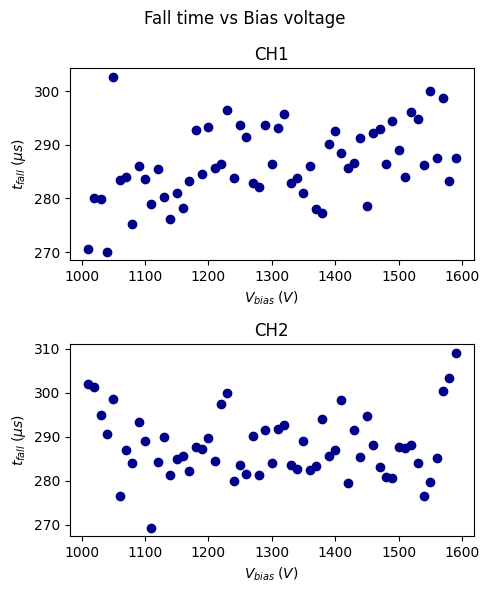

In [35]:
fig, ax = plt.subplots(2, 1, figsize=(5,6))
ax[0].scatter(voltages, fall_times_ch1, label='Fall time', color='darkblue')
ax[0].set_xlabel(r'$V_{bias} \; (V)$')
ax[0].set_ylabel(r'$t_{fall} \; (\mu s)$')
ax[0].set_title('CH1')
ax[1].scatter(voltages, fall_times_ch2, label='Fall time', color='darkblue')
ax[1].set_xlabel(r'$V_{bias} \; (V)$')
ax[1].set_ylabel(r'$t_{fall} \; (\mu s)$')
ax[1].set_title('CH2')

fig.suptitle('Fall time vs Bias voltage')
plt.tight_layout()

# ax.legend()
if SAVE_PLOTS:
    plt.savefig('plots/pmt_signal_tests/pmt1/fall_times.png', dpi=300, bbox_inches='tight')
plt.show()

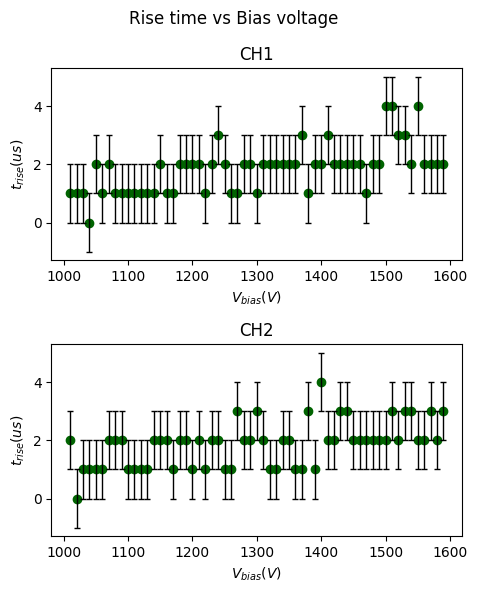

In [36]:
fig, ax = plt.subplots(2,1,figsize=(5,6))
ax[0].scatter(voltages, rise_times_ch1, label='Rise time', color='darkgreen', zorder=2)
ax[0].errorbar(voltages, rise_times_ch1, yerr=1, fmt='none', color='black', capsize=2,capthick=1,elinewidth=1, label='Rise time')

ax[0].set_xlabel(r'$V_{bias} (V)$')
ax[0].set_ylabel(r'$t_{rise} (us)$')
ax[0].set_title('CH1')

ax[1].scatter(voltages, rise_times_ch2, label='Rise time', color='darkgreen', zorder=2)
ax[1].errorbar(voltages, rise_times_ch2, yerr=1, fmt='none', color='black', capsize=2,capthick=1,elinewidth=1, label='Rise time')
ax[1].set_xlabel(r'$V_{bias} (V)$')
ax[1].set_ylabel(r'$t_{rise} (us)$')
ax[1].set_title('CH2')
fig.suptitle('Rise time vs Bias voltage')
plt.tight_layout()


# ax.legend()
if SAVE_PLOTS:
    plt.savefig('plots/pmt_signal_tests/pmt1/rise_times.png', dpi=300, bbox_inches='tight')
plt.show()